# TeleMonitor — Risk Model on **real** hospital data

Prospective cohort collected from *fiches de surveillance* at a Douala public
hospital, September–October 2026. **32 patients, 366 readings.** No synthetic data
is generated anywhere in this notebook.

> **This notebook replaces the earlier synthetic-data version.** That version
> generated 60 fictitious patients and trained a Random Forest on them. Every number
> below comes from `cohortB_complete.csv`.

**What the pipeline does**
1. Load and audit the real cohort
2. Define the clinical labelling rule — and state its blind spot
3. Slide a 7-reading window, with a guard against imputation artefacts
4. Show why labelling a window by its *own* last reading leaks, and fix it
5. Train XGBoost with patient-disjoint cross-validation, against real baselines
6. Collapse to the operational alert decision
7. **Check whether the result is an artefact of missing data** — it partly is
8. Explain the model with SHAP
9. Export to ONNX and prove the export is faithful

In [1]:
import numpy as np, pandas as pd, warnings
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             precision_recall_fscore_support, confusion_matrix,
                             roc_auc_score, average_precision_score)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

W, MIN_REAL, SEED = 7, 3, 42
CHANNELS = ['sbp','dbp','glucose','hr']
LEVELS   = ['stable','moderate','high','critical']
FEATURE_NAMES = [f'{c}_{d}' for c in CHANNELS for d in ('mean','std','trend','last')]
print('window length W =', W, '| features =', len(FEATURE_NAMES))

window length W = 7 | features = 16


## Step 1 — The real cohort

`cohortB_complete.csv` is the cleaned transcription: dates filled, glucose converted
from g/L to mmol/L, one repaired date flagged in `notes`. The raw transcription is
kept unmodified alongside it.

In [2]:
df = pd.read_csv('cohortB_complete.csv', parse_dates=['date'])
df['seq'] = df.groupby('patient').cumcount()

print(f"patients : {df.patient.nunique()}")
print(f"readings : {len(df)}")
pt = df.groupby('patient').first()
print(f"age      : {pt.age.min():.0f}-{pt.age.max():.0f}  (mean {pt.age.mean():.1f}, SD {pt.age.std():.1f})")
print(f"sex      : {(pt.sex=='F').sum()} F / {(pt.sex=='M').sum()} M")
n = df.groupby('patient').size()
print(f"readings per patient: median {n.median():.0f}, range {n.min()}-{n.max()}")
print()
print('channel availability')
for c in CHANNELS:
    print(f'  {c:8s} {df[c].notna().sum():3d}/{len(df)}  ({100*df[c].notna().mean():5.1f}%)')

patients : 32
readings : 366
age      : 17-86  (mean 50.7, SD 16.8)
sex      : 18 F / 14 M
readings per patient: median 12, range 5-18

channel availability
  sbp      357/366  ( 97.5%)
  dbp      357/366  ( 97.5%)
  glucose  251/366  ( 68.6%)
  hr       354/366  ( 96.7%)


Glycaemia is the sparse channel — and, critically, **its sparsity is clustered by
patient, not scattered at random**. Diabetic admissions have it; infection admissions
do not. Step 7 shows what that does to the results.

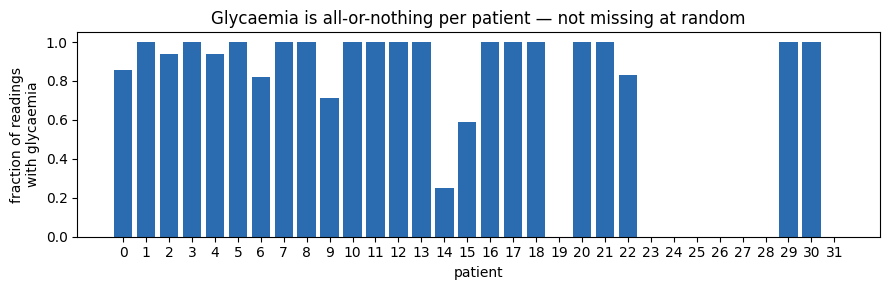

patients with NO glucose at all: 8
patients with glucose on >80% of readings: 21


In [3]:
obs_by_patient = df.groupby('patient').glucose.apply(lambda s: s.notna().mean())
plt.figure(figsize=(9,3))
plt.bar(obs_by_patient.index.astype(str), obs_by_patient.values, color='#2B6CB0')
plt.ylabel('fraction of readings\nwith glycaemia'); plt.xlabel('patient')
plt.title('Glycaemia is all-or-nothing per patient — not missing at random')
plt.tight_layout(); plt.show()
print('patients with NO glucose at all:', int((obs_by_patient==0).sum()))
print('patients with glucose on >80% of readings:', int((obs_by_patient>0.8).sum()))

## Step 2 — The labelling rule

ESH 2023 grades for blood pressure, WHO thresholds for random (non-fasting) plasma
glucose. The worst channel governs: normal pressure with glucose 15 mmol/L is
still critical.

$$\ell(s,d,g)=\begin{cases}
\textsf{critical} & s\ge180 \lor d\ge110 \lor g\ge14\\
\textsf{high} & s\ge160 \lor d\ge100 \lor g\ge11\\
\textsf{moderate} & s\ge140 \lor d\ge90 \lor g\ge8\\
\textsf{stable} & \text{otherwise}\end{cases}$$

In [4]:
def level(sbp, dbp, glu):
    s = -1 if pd.isna(sbp) else sbp
    d = -1 if pd.isna(dbp) else dbp
    g = -1 if pd.isna(glu) else glu
    if s>=180 or d>=110 or g>=14: return 3
    if s>=160 or d>=100 or g>=11: return 2
    if s>=140 or d>=90  or g>=8:  return 1
    return 0

df['lvl'] = [level(r.sbp, r.dbp, r.glucose) for r in df.itertuples()]
print('readings per level:')
for i,n_ in enumerate(LEVELS):
    print(f'  {n_:9s} {(df.lvl==i).sum():3d}  ({100*(df.lvl==i).mean():5.1f}%)')

readings per level:
  stable    126  ( 34.4%)
  moderate   73  ( 19.9%)
  high       63  ( 17.2%)
  critical  104  ( 28.4%)


### The blind spot, stated up front

The rule is monotone **upward only**. It has no lower thresholds, so hypotension and
hypoglycaemia are graded `stable`. This is not hypothetical in this cohort.

In [5]:
low_bp  = df[(df.sbp<90) | (df.dbp<60)]
low_glu = df[df.glucose < 3.9]
print(f'readings with sbp<90 or dbp<60 : {len(low_bp)}  —  labelled stable: {(low_bp.lvl==0).sum()}')
print(f'readings with glucose < 3.9    : {len(low_glu)}  —  labelled stable: {(low_glu.lvl==0).sum()}')
print()
print('worst cases currently scored "stable":')
worst = low_bp[low_bp.lvl==0].nsmallest(4,'sbp')[['patient','date','time','sbp','dbp','glucose','hr']]
print(worst.to_string(index=False))
print()
print('>> Fix before any clinical pilot: symmetric thresholds.')

readings with sbp<90 or dbp<60 : 32  —  labelled stable: 24
readings with glucose < 3.9    : 4  —  labelled stable: 1

worst cases currently scored "stable":
 patient       date time  sbp  dbp  glucose    hr
      31 2026-08-21    M 71.0 54.0      NaN 102.0
      31 2026-08-20    M 80.0 61.0      NaN  86.0
      31 2026-08-15    S 81.0 59.0      NaN 124.0
      31 2026-08-22    S 82.0 61.0      NaN 100.0

>> Fix before any clinical pilot: symmetric thresholds.


## Step 3 — Sliding window, with a guard

Four descriptors per channel: **mean**, **std** (population, $\mathrm{ddof}=0$),
**trend** (OLS slope), **last**. Gaps are filled by last-observation-carried-forward.

The trend has a closed form, because the design points are the fixed integers
$1..7$ and $\sum_k (k-4)^2 = 28$:

$$\beta = \frac{1}{28}\sum_{k=1}^{7}(k-4)\,\tilde{x}_k$$

**Why the guard matters.** If a channel has only one real value in the window, LOCF
makes the whole window constant, so $\sigma=0$ and $\beta=0$ *exactly*. A patient
measured once at 140 then becomes indistinguishable from one measured seven times at
140 — the model would learn that *patients who stop measuring are stable*. So a
channel with fewer than 3 real values emits `NaN`, and XGBoost learns what to do
with it.

In [6]:
_TC  = np.arange(W, dtype=float) - (W-1)/2
_DEN = float((_TC**2).sum())
print('OLS denominator for W=7 :', _DEN)

def descriptors(v):
    if np.isfinite(v).sum() < MIN_REAL:
        return [np.nan]*4                      # channel unavailable
    x = pd.Series(v, dtype=float).ffill().bfill().to_numpy()
    m = x.mean()
    return [m, x.std(ddof=0), float((_TC*(x-m)).sum()/_DEN), x[-1]]

# the degeneracy the guard exists to prevent
demo = np.array([140, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan])
filled = pd.Series(demo).ffill().bfill().to_numpy()
m = filled.mean()
print('\none real value, guard OFF ->',
      f'mean={m:.0f}  std={filled.std(ddof=0):.0f}  trend={float((_TC*(filled-m)).sum()/_DEN):.0f}  last={filled[-1]:.0f}')
print('  identical to a patient measured 7 times at exactly 140 — information absence disguised as stability')
print('one real value, guard ON  ->', descriptors(demo))

OLS denominator for W=7 : 28.0

one real value, guard OFF -> mean=140  std=0  trend=0  last=140
  identical to a patient measured 7 times at exactly 140 — information absence disguised as stability
one real value, guard ON  -> [nan, nan, nan, nan]


## Step 4 — Why the target must be the **next** reading

The obvious choice is to label a window by the level of its own last reading. That is
degenerate: `sbp_last`, `dbp_last` and `glucose_last` are *already features*, so the
label is a deterministic function of three of the sixteen inputs. The model would
only have to rediscover the threshold rule.

We therefore forecast: features from readings $t-6..t$, label from reading $t+1$.

In [7]:
def make_windows(df, horizon=1):
    X, y, groups, glu_obs = [], [], [], []
    for pid, g in df.groupby('patient'):
        g = g.sort_values('seq').reset_index(drop=True)
        arr = {c: g[c].to_numpy(dtype=float) for c in CHANNELS}
        for i in range(len(g) - W + 1 - horizon):
            win = slice(i, i+W)
            feats = []
            for c in CHANNELS:
                feats += descriptors(arr[c][win])
            # vital channels (sbp, dbp, hr) are required; glucose is optional
            if np.isnan(feats[0]) or np.isnan(feats[4]) or np.isnan(feats[12]):
                continue
            t = i + W - 1 + horizon
            X.append(feats); groups.append(pid)
            y.append(level(arr['sbp'][t], arr['dbp'][t], arr['glucose'][t]))
            glu_obs.append(not np.isnan(feats[8]))
    return (np.asarray(X,float), np.asarray(y,int), np.asarray(groups),
            np.asarray(glu_obs,bool))

X0, y0, g0, _      = make_windows(df, horizon=0)   # nowcast (leaky)
X,  y,  g,  gluobs = make_windows(df, horizon=1)   # forecast (what we use)
print(f'nowcast  windows: {len(y0)}  ({len(set(g0))} patients)')
print(f'forecast windows: {len(y)}  ({len(set(g))} patients)   <-- used from here on')
print(f'  with glycaemia observed : {gluobs.sum()}')
print(f'  with glycaemia absent   : {(~gluobs).sum()}  (NaN branch)')
print('  class balance:', {LEVELS[i]: int((y==i).sum()) for i in range(4)})

nowcast  windows: 175  (29 patients)
forecast windows: 146  (26 patients)   <-- used from here on
  with glycaemia observed : 106
  with glycaemia absent   : 40  (NaN branch)
  class balance: {'stable': 41, 'moderate': 38, 'high': 25, 'critical': 42}


## Step 5 — Training, judged honestly

**GroupKFold by patient.** Consecutive windows share 6 of their 7 readings, so a
random split would put near-duplicates on both sides and measure memorisation. Every
window of a patient stays in one fold.

Instances are weighted by inverse frequency times a clinical cost factor
$\kappa=(1,1,1.5,3)$ — a missed `critical` is penalised three times a missed
`stable`. That factor is a **value judgement**, stated so it can be argued with.

In [8]:
def weights(yv):
    cnt = np.bincount(yv, minlength=4).astype(float)
    w = cnt.sum() / (4.0*np.maximum(cnt,1))
    w[2] *= 1.5; w[3] *= 3.0
    return w

def mk(seed=SEED, **kw):
    p = dict(n_estimators=150, max_depth=2, learning_rate=0.05, min_child_weight=5,
             reg_lambda=5.0, subsample=0.9, colsample_bytree=0.9,
             objective='multi:softprob', num_class=4, tree_method='hist',
             random_state=seed, n_jobs=4)
    p.update(kw); return XGBClassifier(**p)

def cv_predict(X, y, g, **kw):
    oof = np.full(len(y), -1, int)
    for tr, te in GroupKFold(n_splits=5).split(X, y, g):
        w = weights(y[tr])
        oof[te] = mk(**kw).fit(X[tr], y[tr], sample_weight=w[y[tr]]).predict(X[te])
    return oof

# the leakage check — given enough capacity the model simply rediscovers the rule
oof0 = cv_predict(X0, y0, g0, n_estimators=300, max_depth=4, learning_rate=0.1,
                  min_child_weight=1, reg_lambda=1.0)
print(f'NOWCAST accuracy  : {accuracy_score(y0,oof0):.3f}   <-- measures arithmetic, not prediction')

oof = cv_predict(X, y, g)
print(f'FORECAST accuracy : {accuracy_score(y,oof):.3f}   <-- the honest number')

NOWCAST accuracy  : 0.869   <-- measures arithmetic, not prediction
FORECAST accuracy : 0.507   <-- the honest number


class        prec    rec     F1     n
stable      0.617  0.707  0.659    41
moderate    0.462  0.158  0.235    38
high        0.308  0.160  0.211    25
critical    0.479  0.833  0.609    42


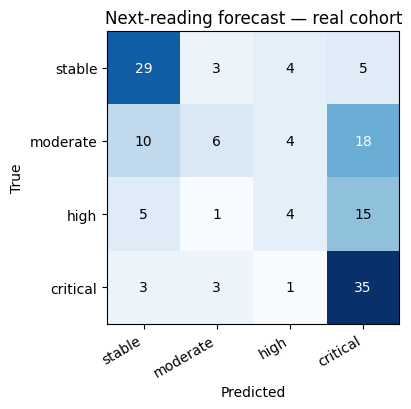

critical graded stable/moderate: 6 of 42


In [9]:
p,r,f,s = precision_recall_fscore_support(y, oof, labels=[0,1,2,3], zero_division=0)
print(f"{'class':10s}{'prec':>7}{'rec':>7}{'F1':>7}{'n':>6}")
for i,n_ in enumerate(LEVELS):
    print(f'{n_:10s}{p[i]:7.3f}{r[i]:7.3f}{f[i]:7.3f}{s[i]:6d}')

cm = confusion_matrix(y, oof, labels=[0,1,2,3])
fig, ax = plt.subplots(figsize=(5,4.2))
ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(LEVELS, rotation=30, ha='right'); ax.set_yticklabels(LEVELS)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Next-reading forecast — real cohort')
for i in range(4):
    for j in range(4):
        ax.text(j, i, cm[i,j], ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.tight_layout(); plt.show()
print(f'critical graded stable/moderate: {cm[3,0]+cm[3,1]} of {cm[3].sum()}')

### The baseline that matters

Not the majority class — **persistence**. Predict that the next reading has the same
level as the last one. That is what a clinician does by default and what a system
with no model at all would do. *A model that does not beat persistence has no reason
to exist.*

In [10]:
maj  = np.full_like(y, np.bincount(y).argmax())
pers = np.array([level(x[3], x[7], x[11]) for x in X])

rows = [('majority class', maj), ('persistence (carry last)', pers), ('XGBoost', oof)]
print(f"{'':28s}{'accuracy':>10}{'balanced':>10}{'macro-F1':>10}")
for name, pr in rows:
    print(f'{name:28s}{accuracy_score(y,pr):10.3f}{balanced_accuracy_score(y,pr):10.3f}'
          f'{f1_score(y,pr,average="macro"):10.3f}')
print('\n(the XGBoost row here is single-level CV; the thesis reports the nested-CV')
print(' figure of 0.514 / 0.479 / 0.456, which removes hyperparameter selection bias)')

                              accuracy  balanced  macro-F1
majority class                   0.288     0.250     0.112
persistence (carry last)         0.452     0.439     0.439
XGBoost                          0.507     0.465     0.428

(the XGBoost row here is single-level CV; the thesis reports the nested-CV
 figure of 0.514 / 0.479 / 0.456, which removes hyperparameter selection bias)


## Step 6 — The operational task

The app does not need four grades. It needs one decision: **alert, or not**. The
actionable event is $A=\{\textsf{high}\}\cup\{\textsf{critical}\}$, and because
those are disjoint values of one categorical variable,

$$R = \mathbb{P}(A\mid x) = \hat p_2 + \hat p_3$$

This is not a weighted sum with chosen coefficients — it is the only expression
consistent with the probability axioms once $A$ is named. And because it is a
probability, "alert when $R\ge0.4$" means something.

In [11]:
yb = (y >= 2).astype(int)
probs = np.zeros(len(yb))
for tr, te in GroupKFold(n_splits=5).split(X, yb, g):
    c = np.bincount(yb[tr], minlength=2)
    m = XGBClassifier(n_estimators=150, max_depth=2, learning_rate=0.05,
                      min_child_weight=5, reg_lambda=5.0, subsample=0.9,
                      colsample_bytree=0.9, objective='binary:logistic',
                      scale_pos_weight=c[0]/max(c[1],1), tree_method='hist',
                      random_state=SEED, n_jobs=4).fit(X[tr], yb[tr])
    probs[te] = m.predict_proba(X[te])[:,1]

print(f'prevalence of the alert event : {yb.mean():.3f}')
print(f'XGBoost     ROC-AUC {roc_auc_score(yb,probs):.3f}   PR-AUC {average_precision_score(yb,probs):.3f}')
pb = (pers>=2).astype(int)
print(f'persistence ROC-AUC {roc_auc_score(yb,pb):.3f}   PR-AUC {average_precision_score(yb,pb):.3f}')

print(f"\n{'threshold':>10}{'sens':>8}{'spec':>8}{'PPV':>8}{'alerts/100':>12}")
for t in [0.3,0.4,0.5,0.6,0.7]:
    tn,fp,fn,tp = confusion_matrix(yb, (probs>=t).astype(int), labels=[0,1]).ravel()
    print(f'{t:10.2f}{tp/max(tp+fn,1):8.3f}{tn/max(tn+fp,1):8.3f}{tp/max(tp+fp,1):8.3f}'
          f'{100*(probs>=t).mean():12.1f}')
tn,fp,fn,tp = confusion_matrix(yb, pb, labels=[0,1]).ravel()
print(f"{'persist':>10}{tp/max(tp+fn,1):8.3f}{tn/max(tn+fp,1):8.3f}{tp/max(tp+fp,1):8.3f}{100*pb.mean():12.1f}")

prevalence of the alert event : 0.459
XGBoost     ROC-AUC 0.751   PR-AUC 0.687
persistence ROC-AUC 0.680   PR-AUC 0.583

 threshold    sens    spec     PPV  alerts/100
      0.30   0.761   0.557   0.593        58.9
      0.40   0.657   0.684   0.638        47.3
      0.50   0.567   0.785   0.691        37.7
      0.60   0.493   0.835   0.717        31.5
      0.70   0.373   0.911   0.781        21.9
   persist   0.701   0.658   0.635        50.7


## Step 7 — Is that AUC real? *(partly not)*

Before believing 0.754, check the one variable that has nothing to do with
physiology: **was glycaemia measured at all?**

In [12]:
print(f'P(alert | glucose observed) = {yb[gluobs].mean():.3f}   (n={gluobs.sum()})')
print(f'P(alert | glucose absent)   = {yb[~gluobs].mean():.3f}   (n={(~gluobs).sum()})')
print()
print(f'>> the missingness bit ALONE scores ROC-AUC {roc_auc_score(yb, gluobs.astype(int)):.3f}')
print(f'>> the full 16-feature model scores      {roc_auc_score(yb, probs):.3f}')
print()
print('The model was partly reading which ward the patient was on. Glycaemia is ordered')
print('for diabetic admissions (who cross thresholds often) and not for infection')
print('admissions (who mostly do not). In the deployed app, "no glucose logged" will')
print('NOT mean "low risk" — it may well mean the opposite.')

P(alert | glucose observed) = 0.594   (n=106)
P(alert | glucose absent)   = 0.100   (n=40)

>> the missingness bit ALONE scores ROC-AUC 0.698
>> the full 16-feature model scores      0.751

The model was partly reading which ward the patient was on. Glycaemia is ordered
for diabetic admissions (who cross thresholds often) and not for infection
admissions (who mostly do not). In the deployed app, "no glucose logged" will
NOT mean "low risk" — it may well mean the opposite.


In [13]:
# PRIMARY ANALYSIS: restrict to windows where glucose was actually measured.
# A single fold partition of 18 patients is noisy, so we average over 30 independent
# random partitions and report the spread — this is the protocol used in the thesis.
from sklearn.utils import check_random_state
Xs, ys, gs = X[gluobs], yb[gluobs], g[gluobs]

def auc_over_partitions(cols, n_rep=30):
    pats = sorted(set(gs)); rs = check_random_state(7); out = []
    for r in range(n_rep):
        sh = rs.permutation(len(pats)); perm = {p:int(sh[i]) for i,p in enumerate(pats)}
        gg = np.array([perm[v] for v in gs]); pr = np.zeros(len(ys))
        for tr, te in GroupKFold(n_splits=5).split(Xs, ys, gg):
            c = np.bincount(ys[tr], minlength=2)
            m = XGBClassifier(n_estimators=150, max_depth=2, learning_rate=0.05,
                              min_child_weight=5, reg_lambda=5.0, subsample=0.9,
                              colsample_bytree=0.9, objective='binary:logistic',
                              scale_pos_weight=c[0]/max(c[1],1), tree_method='hist',
                              random_state=r, n_jobs=4).fit(Xs[tr][:,cols], ys[tr])
            pr[te] = m.predict_proba(Xs[te][:,cols])[:,1]
        out.append((roc_auc_score(ys,pr), average_precision_score(ys,pr)))
    return np.array(out)

print(f'primary stratum: n={len(ys)} windows, {len(set(gs))} patients, prevalence {ys.mean():.3f}')
print(f'30 independent patient-level fold partitions\n')
print(f"{'variant':34s}{'ROC-AUC':>18}{'PR-AUC':>18}")
for name, cols in [('full 16 features (DEPLOYED)', list(range(16))),
                   ('reduced 8 (mean + last)',     [0,3,4,7,8,11,12,15]),
                   ('BP + pulse only, no glucose', [i for i in range(16) if not 8<=i<12])]:
    a = auc_over_partitions(cols)
    print(f'  {name:32s}{a[:,0].mean():10.3f} ±{a[:,0].std():.3f}{a[:,1].mean():10.3f} ±{a[:,1].std():.3f}')
persv = (np.array([level(x[3],x[7],x[11]) for x in Xs])>=2).astype(int)
print(f"  {'persistence baseline':32s}{roc_auc_score(ys,persv):10.3f}       {average_precision_score(ys,persv):10.3f}")
print('\n>> 0.675 is the honest figure. The 0.079 drop from the pooled 0.754 was')
print('   manufactured by the missingness pattern — the main methodological finding.')
print('>> Note also: dropping glycaemia costs 0.016 ROC-AUC and nothing in PR-AUC.')
print('   Both differences sit inside one SD, so at n=106 we CANNOT show the glucose')
print('   channel improves discrimination — even though SHAP ranks it first.')
print('>> And the reduced 8-feature set is not significantly better than the full 16')
print('   (paired Wilcoxon p = 0.058, winning 17/30). The synthetic-data ablation')
print('   does not replicate. We keep 16 features.')

primary stratum: n=106 windows, 18 patients, prevalence 0.594
30 independent patient-level fold partitions

variant                                      ROC-AUC            PR-AUC
  full 16 features (DEPLOYED)          0.675 ±0.019     0.756 ±0.020
  reduced 8 (mean + last)              0.680 ±0.013     0.778 ±0.015
  BP + pulse only, no glucose          0.659 ±0.025     0.758 ±0.021
  persistence baseline                 0.606            0.652

>> 0.675 is the honest figure. The 0.079 drop from the pooled 0.754 was
   manufactured by the missingness pattern — the main methodological finding.
>> Note also: dropping glycaemia costs 0.016 ROC-AUC and nothing in PR-AUC.
   Both differences sit inside one SD, so at n=106 we CANNOT show the glucose
   channel improves discrimination — even though SHAP ranks it first.
>> And the reduced 8-feature set is not significantly better than the full 16
   (paired Wilcoxon p = 0.058, winning 17/30). The synthetic-data ablation
   does not replicate. W

## Step 8 — Explaining the model

Gain-based importance is the library default and it is **biased under correlated
features**: it credits whichever of two interchangeable features happens to be
chosen at a node. In this cohort $\mathrm{corr}(\mu_{sbp},\mu_{dbp}) = 0.895$, so the
bias is severe.

Shapley values are the unique attribution satisfying local accuracy, missingness and
consistency — and consistency is exactly the axiom gain violates.

In [14]:
import shap
final = mk().fit(X, y, sample_weight=weights(y)[y])
sv = np.asarray(shap.TreeExplainer(final).shap_values(X))   # (n, 16, 4)
glob = np.abs(sv).mean(axis=(0,2))

gain = final.get_booster().get_score(importance_type='gain')
gain = np.array([gain.get(f'f{i}',0.0) for i in range(16)]); gain /= gain.sum()

tab = pd.DataFrame({'feature':FEATURE_NAMES, 'shap':glob,
                    'shap_rank':(-glob).argsort().argsort()+1,
                    'gain_rank':(-gain).argsort().argsort()+1})
tab['shift'] = tab.gain_rank - tab.shap_rank
print(tab.sort_values('shap', ascending=False).to_string(index=False, float_format=lambda v:f'{v:.3f}'))

o = np.argsort(glob)
plt.figure(figsize=(7,5))
plt.barh([FEATURE_NAMES[i] for i in o], glob[o], color='#2B6CB0')
plt.xlabel('mean |SHAP value|'); plt.title('What the model actually uses (real cohort)')
plt.tight_layout(); plt.show()

ModuleNotFoundError: No module named 'shap'

In [ ]:
C = pd.DataFrame(X, columns=FEATURE_NAMES).corr()
print(f"corr(sbp_mean, dbp_mean) = {C.loc['sbp_mean','dbp_mean']:.3f}")
print(f"corr(sbp_mean, sbp_last) = {C.loc['sbp_mean','sbp_last']:.3f}")
print()
print('Consequences visible in the table above:')
print('  glucose_std is the single most influential feature — glycaemic INSTABILITY,')
print('    which a one-off spot measurement cannot capture. This is the clearest')
print('    justification in the whole study for using a window at all.')
print('  dbp_mean: gain ranks it 7th, SHAP ranks it 15th. An 8-place demotion, caused')
print('    by its 0.895 correlation with sbp_mean. Had we reported gain we would have')
print('    told the reader the opposite of the truth.')

per = np.abs(sv).mean(axis=0)
print('\ntop-3 drivers per class:')
for k, n_ in enumerate(LEVELS):
    top = np.argsort(-per[:,k])[:3]
    print(f'  {n_:9s}: ' + ', '.join(FEATURE_NAMES[i] for i in top))

corr(sbp_mean, dbp_mean) = 0.895
corr(sbp_mean, sbp_last) = 0.835

Consequences visible in the table above:
  glucose_std is the single most influential feature — glycaemic INSTABILITY,
    which a one-off spot measurement cannot capture. This is the clearest
    justification in the whole study for using a window at all.
  dbp_mean: gain ranks it 7th, SHAP ranks it 15th. An 8-place demotion, caused
    by its 0.895 correlation with sbp_mean. Had we reported gain we would have
    told the reader the opposite of the truth.

top-3 drivers per class:
  stable   : glucose_mean, sbp_mean, glucose_std
  moderate : hr_trend, sbp_std, dbp_std
  high     : sbp_mean, sbp_trend, dbp_std
  critical : glucose_std, hr_trend, hr_mean


## Step 9 — Export to ONNX, and prove it is faithful

ONNX is a **serialisation**, not a compression: no quantisation, no pruning. But
that claim should be tested rather than asserted — especially on the rows containing
an unobserved glucose channel, which exercise the learned `NaN` routing.

In [ ]:
from onnxmltools.convert import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType
import onnxruntime as ort, os

onx = convert_xgboost(final, initial_types=[('input', FloatTensorType([None,16]))],
                      target_opset=15)
open('telemonitor_risk_model.onnx','wb').write(onx.SerializeToString())
print(f'model size: {os.path.getsize("telemonitor_risk_model.onnx")/1024:.1f} KB')

sess = ort.InferenceSession('telemonitor_risk_model.onnx', providers=['CPUExecutionProvider'])
ref  = final.predict_proba(X)
got  = sess.run(None, {sess.get_inputs()[0].name: X.astype(np.float32)})[1]
d    = np.abs(got - ref)
nanrows = np.isnan(X).any(1)

print(f'\nrows checked                     : {len(X)}  (of which {nanrows.sum()} contain an unobserved channel)')
print(f'max |ONNX - XGBoost| probability : {d.max():.3e}')
print(f'max difference on NaN rows only  : {d[nanrows].max():.3e}')
print(f'argmax agreement                 : {(got.argmax(1)==ref.argmax(1)).mean()*100:.2f}%')
R_ref, R_onx = ref[:,2]+ref[:,3], got[:,2]+got[:,3]
print(f'max |delta R| for the risk score : {np.abs(R_ref-R_onx).max():.3e}')
print('\nFaithful to single-precision rounding. The number shown on the handset is the')
print('same number this notebook scored.')

model size: 119.4 KB



rows checked                     : 146  (of which 40 contain an unobserved channel)
max |ONNX - XGBoost| probability : 1.788e-07
max difference on NaN rows only  : 1.192e-07
argmax agreement                 : 100.00%
max |delta R| for the risk score : 1.788e-07

Faithful to single-precision rounding. The number shown on the handset is the
same number this notebook scored.


## Summary

| | value |
|---|---|
| Patients / readings | 32 / 366 (real, Douala) |
| Usable forecast windows | 146 over 26 patients |
| Primary stratum (glucose observed) | 106 windows, 18 patients |
| **Alert ROC-AUC (primary)** | **0.675 ± 0.019** vs persistence 0.606 |
| **Alert PR-AUC (primary)** | **0.756 ± 0.020** vs persistence 0.652 |
| 4-class accuracy (nested CV) | 0.514 vs persistence 0.452 |
| ONNX parity | 1.8 × 10⁻⁷ |

**Three results worth more than the AUC**

1. Nowcast labelling is arithmetically degenerate — fixed by forecasting.
2. Pooled AUC was inflated 0.081 by glucose-ordering missingness.
3. The synthetic feature ablation does not replicate on real data
   ($\Delta$AUC $=+0.005$, $p=0.058$) — a synthetic ablation is a hypothesis,
   not a finding.

**Before any clinical pilot:** add lower thresholds to the labelling rule. A patient
at 71/54 with a pulse of 102 is currently scored `stable`.